In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pickle
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [218]:
import pickle
import pickle
with open('/content/drive/MyDrive/video_features_256.pkl', 'rb') as f:
    video_256 = pickle.load(f)
with open('/content/drive/MyDrive/video_features_768.pkl', 'rb') as f:
    video_768 = pickle.load(f)

with open('/content/drive/MyDrive/audio_feat_hubert_origin.pkl', 'rb') as f:
    audio_256 = pickle.load(f)
with open('/content/drive/MyDrive/audio_feat_hubert_aug.pkl', 'rb') as f:
    audio_256_aug = pickle.load(f)
with open('/content/drive/MyDrive/audio_hubert_768.pkl', 'rb') as f:
    audio_768 = pickle.load(f)


text_256 = torch.load('/content/drive/MyDrive/text_features_256(basic+earlystop).pkl',  map_location='cpu')
text_768 = torch.load('/content/drive/MyDrive/text_features_768(basic+earlystop).pkl',  map_location='cpu')
text_256_aug = torch.load('/content/drive/MyDrive/text_features_256(basic+earlystop).pkl',  map_location='cpu')
text_768_aug = torch.load('/content/drive/MyDrive/text_features_768(basic+earlystop).pkl',  map_location='cpu')

y_all=text_256['labels']

In [220]:
# 조합 1
X_video=video_256['features']
X_audio=audio_256['audio_feat']
X_text=text_256['features']

In [239]:
# 조합 2
X_video=video_256['features']
X_audio=audio_256['audio_feat']
X_text=text_256_aug['features']

In [258]:
# 조합 3
X_video=video_768['features']
X_audio=audio_768['audio_feat']
X_text=text_768['features']

In [289]:
# 조합 4
X_video=video_768['features']
X_audio=audio_768['audio_feat']
X_text=text_768_aug['features']

In [308]:
# 조합 5
X_video=video_256['features']
X_audio=audio_256_aug['audio_feat']
X_text=text_256_aug['features']

In [326]:
# 조합 6
X_video=video_256['features']
X_audio=audio_256_aug['audio_feat']
X_text=text_256['features']

In [290]:
print(X_video.shape)
print(X_audio.shape)
print(X_text.shape)

torch.Size([2199, 768])
torch.Size([2199, 768])
torch.Size([2199, 768])


In [327]:
X_video = F.normalize(X_video, dim=-1).detach()
X_audio = F.normalize(X_audio, dim=-1).detach()
X_text = F.normalize(X_text, dim=-1).detach()

In [328]:
class MultiModalDataset(Dataset):
    def __init__(self, video_features, audio_features, text_features, labels):
        self.video_features = video_features
        self.audio_features = audio_features
        self.text_features = text_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        video = self.video_features[idx]
        audio = self.audio_features[idx]
        text = self.text_features[idx]
        label = self.labels[idx]
        return video, audio, text, label

# --- Train / Val / Test   분리 ---
idx = np.arange(len(y_all))
idx_tr, idx_temp = train_test_split(idx, test_size=0.3, random_state=42, stratify=y_all)
idx_te, idx_val = train_test_split(idx_temp, test_size=0.5, random_state=42, stratify=y_all[idx_temp])

train_set = MultiModalDataset(X_video[idx_tr], X_audio[idx_tr], X_text[idx_tr], y_all[idx_tr])
val_set   = MultiModalDataset(X_video[idx_val], X_audio[idx_val], X_text[idx_val], y_all[idx_val])
test_set  = MultiModalDataset(X_video[idx_te], X_audio[idx_te], X_text[idx_te], y_all[idx_te])

BATCH_SIZE = 16
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_set)}/ Val: {len(val_set)} / Test: {len(test_set)}")
v, a, t, lab = next(iter(train_loader))
print(f"video {tuple(v.shape)}  audio {tuple(a.shape)}  text {tuple(t.shape)}")

Train: 1539/ Val: 330 / Test: 330
video (16, 256)  audio (16, 256)  text (16, 256)


In [329]:
class GraphMiddleFusionModel(nn.Module):
    # GCN 기반 멀티모달 융합
    def __init__(self, input_dim=768,shared_dim=256, num_gnn_layers=1, num_classes=2,  adjacency=None):
        super().__init__()
        self.input_dim = input_dim
        # --- 1) 차원 통일 ---
        self.video_proj = nn.Linear(input_dim, shared_dim)
        self.audio_proj = nn.Linear(input_dim, shared_dim)
        self.text_proj  = nn.Linear(input_dim, shared_dim)

        # --- 2) 인접 행렬 (3×3) - 행별 정규화 후 buffer 등록 ---
        if adjacency is not None:
            A = torch.tensor(adjacency, dtype=torch.float32)
        else:
            A = torch.ones(3,3)
        self.register_buffer("A", A/A.sum(dim=1, keepdim=True))

        # --- 3) 메시지 패싱 레이어 (각 layer = 학습 가능한 W) ---
        self.gnn_layers = nn.ModuleList([
            nn.Linear(shared_dim, shared_dim) for _ in range(num_gnn_layers)
        ])

        # --- 4) 분류기 ---
        self.classifier = nn.Sequential(
            nn.Linear(shared_dim* 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, v, a, t):
        # 1) 차원 통일
        if self.input_dim == 768:
            v = F.relu(self.video_proj(v))
            a = F.relu(self.audio_proj(a))
            t = F.relu(self.text_proj(t))

        # 2) 노드 행렬 H: (B, 3, shared_dim)
        H = torch.stack([v,a,t], dim=1)

        # 3) 메시지 패싱 N번 — H' = ReLU(A · layer(H))
        for layer in self.gnn_layers:
            H = F.relu(self.A @ layer(H))

        # 4) 노드 표현을 펼쳐서 분류
        return self.classifier(H.flatten(1))

In [330]:
class EarlyStopping:
    def __init__(self, patience=2, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [331]:
def train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=20, lr=1e-3, label=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adagrad(model.parameters(), lr=lr,)
    early_stopping = EarlyStopping(patience=2, min_delta=0.001)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_acc": 0,"test_loss":0, "all_pred":[], "all_y":[]}

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for v, a, t, yb in train_loader:
            v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
            out = model(v, a, t)
            loss = criterion(out, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * yb.size(0)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += yb.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total * 100

        model.eval()
        total_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for v, a, t, yb in val_loader:
                v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
                out = model(v, a, t)
                loss = criterion(out, yb)
                total_loss += loss.item() * yb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_loss = total_loss / total
        val_acc = correct / total * 100

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{label}] Epoch {epoch+1:2d}  Train Loss: {train_loss:.4f} | TrainAcc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | ValAcc: {val_acc:.2f}%")

        early_stopping(val_loss)

        if early_stopping.early_stop:
          print("Early stopping")
          break

    # test
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
      for v,a,t, yb in test_loader:
        v, a, t, yb = v.to(device), a.to(device), t.to(device), yb.to(device)
        out = model(v, a, t)
        loss = criterion(out, yb)
        total_loss += loss.item() * yb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
        pred = out.argmax(dim=1)
        history["all_y"].append(yb.cpu())
        history["all_pred"].append(pred.cpu())
    all_y= torch.cat(history["all_y"]).numpy()
    all_pred = torch.cat(history["all_pred"]).numpy()
    test_loss = total_loss / total
    test_acc = correct / total * 100

    history["test_acc"] = test_acc
    history["test_loss"] = test_loss
    print(f"\n[{label}] TestLoss: {test_loss:.4f} | TestAcc: {test_acc:.2f}%")

    return history

In [332]:
assign_results = {}

In [333]:
NUM_EPOCHS  = 20
LR          = 1e-3
input_dim  = X_video.shape[1]
NUM_GNN     = 1
A = [
    [1, 1, 1], # V
    [1, 1, 1], # A
    [1, 1, 1], # T
]
run_name='full connect'

model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3881 | TrainAcc: 91.16% | Val Loss: 0.2935 | ValAcc: 90.00%
[GCN] Epoch  2  Train Loss: 0.2201 | TrainAcc: 92.92% | Val Loss: 0.2729 | ValAcc: 89.70%
[GCN] Epoch  3  Train Loss: 0.2065 | TrainAcc: 93.05% | Val Loss: 0.2656 | ValAcc: 90.30%
[GCN] Epoch  4  Train Loss: 0.1991 | TrainAcc: 93.11% | Val Loss: 0.2606 | ValAcc: 90.00%
[GCN] Epoch  5  Train Loss: 0.1897 | TrainAcc: 93.18% | Val Loss: 0.2586 | ValAcc: 90.00%
[GCN] Epoch  6  Train Loss: 0.1898 | TrainAcc: 93.24% | Val Loss: 0.2583 | ValAcc: 90.00%
[GCN] Epoch  7  Train Loss: 0.1837 | TrainAcc: 93.31% | Val Loss: 0.2548 | ValAcc: 90.61%
[GCN] Epoch  8  Train Loss: 0.1833 | TrainAcc: 93.44% | Val Loss: 0.2549 | ValAcc: 90.61%
[GCN] Epoch  9  Train Loss: 0.1821 | TrainAcc: 93.50% | Val Loss: 0.2555 | ValAcc: 90.61%
Early stopping

[GCN] TestLoss: 0.3596 | TestAcc: 87.58%


In [334]:
A = [
    [1, 0, 0], # V
    [0, 1, 0], # A
    [0, 0, 1], # T
]
run_name='self connect'

model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3449 | TrainAcc: 91.42% | Val Loss: 0.2949 | ValAcc: 88.79%
[GCN] Epoch  2  Train Loss: 0.2162 | TrainAcc: 92.92% | Val Loss: 0.2777 | ValAcc: 89.39%
[GCN] Epoch  3  Train Loss: 0.2013 | TrainAcc: 93.18% | Val Loss: 0.2692 | ValAcc: 89.39%
[GCN] Epoch  4  Train Loss: 0.1852 | TrainAcc: 93.24% | Val Loss: 0.2675 | ValAcc: 89.70%
[GCN] Epoch  5  Train Loss: 0.1819 | TrainAcc: 93.11% | Val Loss: 0.2620 | ValAcc: 90.30%
[GCN] Epoch  6  Train Loss: 0.1782 | TrainAcc: 93.63% | Val Loss: 0.2649 | ValAcc: 90.30%
[GCN] Epoch  7  Train Loss: 0.1778 | TrainAcc: 93.57% | Val Loss: 0.2632 | ValAcc: 90.61%
Early stopping

[GCN] TestLoss: 0.3552 | TestAcc: 87.58%


In [335]:
A = [
    [1, 0, 1], # V
    [0, 1, 1], # A
    [0, 0, 1], # T
]
run_name='self connect + v,a->t'

model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=2e-3, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.2787 | TrainAcc: 92.07% | Val Loss: 0.3179 | ValAcc: 87.88%
[GCN] Epoch  2  Train Loss: 0.2366 | TrainAcc: 92.53% | Val Loss: 0.2977 | ValAcc: 88.79%
[GCN] Epoch  3  Train Loss: 0.2221 | TrainAcc: 92.72% | Val Loss: 0.2844 | ValAcc: 89.39%
[GCN] Epoch  4  Train Loss: 0.2110 | TrainAcc: 92.79% | Val Loss: 0.2778 | ValAcc: 89.39%
[GCN] Epoch  5  Train Loss: 0.2035 | TrainAcc: 93.11% | Val Loss: 0.2663 | ValAcc: 89.70%
[GCN] Epoch  6  Train Loss: 0.1950 | TrainAcc: 93.05% | Val Loss: 0.2751 | ValAcc: 88.79%
[GCN] Epoch  7  Train Loss: 0.1889 | TrainAcc: 92.85% | Val Loss: 0.2587 | ValAcc: 90.91%
[GCN] Epoch  8  Train Loss: 0.1819 | TrainAcc: 93.76% | Val Loss: 0.2594 | ValAcc: 90.30%
[GCN] Epoch  9  Train Loss: 0.1821 | TrainAcc: 93.44% | Val Loss: 0.2571 | ValAcc: 90.61%
[GCN] Epoch 10  Train Loss: 0.1762 | TrainAcc: 93.50% | Val Loss: 0.2559 | ValAcc: 90.61%
[GCN] Epoch 11  Train Loss: 0.1737 | TrainAcc: 93.89% | Val Loss: 0.2550 | ValAcc: 90.61%
[GCN] Epoc

In [336]:
A = [
    [1, 1, 0], # V
    [1, 1, 0], # A
    [0, 0, 1], # T
]
run_name='self connect + v<->a'
model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3807 | TrainAcc: 90.38% | Val Loss: 0.3069 | ValAcc: 88.48%
[GCN] Epoch  2  Train Loss: 0.2288 | TrainAcc: 92.92% | Val Loss: 0.2817 | ValAcc: 89.09%
[GCN] Epoch  3  Train Loss: 0.2054 | TrainAcc: 93.11% | Val Loss: 0.2711 | ValAcc: 89.39%
[GCN] Epoch  4  Train Loss: 0.1988 | TrainAcc: 92.98% | Val Loss: 0.2661 | ValAcc: 90.00%
[GCN] Epoch  5  Train Loss: 0.1951 | TrainAcc: 92.98% | Val Loss: 0.2617 | ValAcc: 90.00%
[GCN] Epoch  6  Train Loss: 0.1863 | TrainAcc: 93.24% | Val Loss: 0.2598 | ValAcc: 90.61%
[GCN] Epoch  7  Train Loss: 0.1813 | TrainAcc: 93.18% | Val Loss: 0.2625 | ValAcc: 90.30%
[GCN] Epoch  8  Train Loss: 0.1787 | TrainAcc: 93.70% | Val Loss: 0.2652 | ValAcc: 89.39%
Early stopping

[GCN] TestLoss: 0.3558 | TestAcc: 87.88%


In [337]:
A = [
    [1, 0, 0], # V
    [0, 1, 0], # A
    [1, 1, 1], # T
]
run_name='self connect + t->va'
model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.4603 | TrainAcc: 89.28% | Val Loss: 0.3447 | ValAcc: 86.36%
[GCN] Epoch  2  Train Loss: 0.2261 | TrainAcc: 93.37% | Val Loss: 0.2712 | ValAcc: 88.48%
[GCN] Epoch  3  Train Loss: 0.1882 | TrainAcc: 93.96% | Val Loss: 0.2620 | ValAcc: 88.79%
[GCN] Epoch  4  Train Loss: 0.1780 | TrainAcc: 93.63% | Val Loss: 0.2625 | ValAcc: 88.79%
[GCN] Epoch  5  Train Loss: 0.1763 | TrainAcc: 93.76% | Val Loss: 0.2608 | ValAcc: 89.09%
[GCN] Epoch  6  Train Loss: 0.1702 | TrainAcc: 93.83% | Val Loss: 0.2620 | ValAcc: 89.09%
[GCN] Epoch  7  Train Loss: 0.1708 | TrainAcc: 93.63% | Val Loss: 0.2603 | ValAcc: 90.00%
Early stopping

[GCN] TestLoss: 0.3700 | TestAcc: 86.36%


In [338]:
A = [
    [1, 1, 1], # V
    [1, 1, 1], # A
    [0, 0, 1], # T
]
run_name='self connect + v<->a, va->t'
model =GraphMiddleFusionModel(input_dim=input_dim, num_gnn_layers=NUM_GNN, num_classes=2, adjacency=A).to(device)
history=train_test_fusion(model, train_loader, val_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR, label="GCN")
assign_results[run_name] = history

[GCN] Epoch  1  Train Loss: 0.3642 | TrainAcc: 92.20% | Val Loss: 0.3217 | ValAcc: 87.58%
[GCN] Epoch  2  Train Loss: 0.2503 | TrainAcc: 92.66% | Val Loss: 0.3114 | ValAcc: 87.88%
[GCN] Epoch  3  Train Loss: 0.2372 | TrainAcc: 92.72% | Val Loss: 0.3041 | ValAcc: 88.18%
[GCN] Epoch  4  Train Loss: 0.2290 | TrainAcc: 92.72% | Val Loss: 0.2983 | ValAcc: 88.18%
[GCN] Epoch  5  Train Loss: 0.2248 | TrainAcc: 92.92% | Val Loss: 0.2923 | ValAcc: 88.79%
[GCN] Epoch  6  Train Loss: 0.2213 | TrainAcc: 92.92% | Val Loss: 0.2874 | ValAcc: 89.09%
[GCN] Epoch  7  Train Loss: 0.2156 | TrainAcc: 92.79% | Val Loss: 0.2819 | ValAcc: 90.00%
[GCN] Epoch  8  Train Loss: 0.2083 | TrainAcc: 92.98% | Val Loss: 0.2784 | ValAcc: 90.00%
[GCN] Epoch  9  Train Loss: 0.2075 | TrainAcc: 92.92% | Val Loss: 0.2754 | ValAcc: 89.39%
[GCN] Epoch 10  Train Loss: 0.2042 | TrainAcc: 92.92% | Val Loss: 0.2720 | ValAcc: 89.39%
[GCN] Epoch 11  Train Loss: 0.2024 | TrainAcc: 93.05% | Val Loss: 0.2693 | ValAcc: 89.70%
[GCN] Epoc

In [339]:
# run_name='self connect + v,a->t'

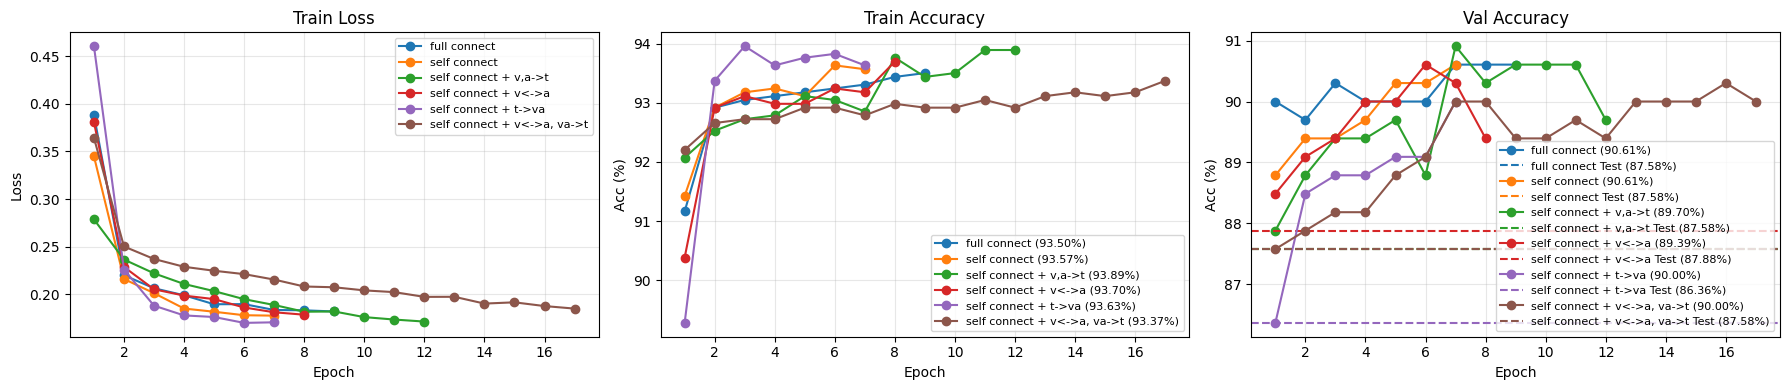


[self connect + v<->a, va->t] 최종 Test Acc: 87.58%
누적된 실험 (6개): ['full connect', 'self connect', 'self connect + v,a->t', 'self connect + v<->a', 'self connect + t->va', 'self connect + v<->a, va->t']


In [340]:

fig_a, ax_a = plt.subplots(1, 3, figsize=(18, 4))
plt.close(fig_a)

assign_results[run_name] = history
from IPython.display import display

for ax in ax_a:
    ax.clear()
for name, h in assign_results.items():
    ep = range(1, len(h["train_loss"]) + 1)
    ax_a[0].plot(ep, h["train_loss"], "-o", label=name)
    ax_a[1].plot(ep, h["train_acc"], "-o", label=f"{name} ({h['train_acc'][-1]:.2f}%)")
    line=ax_a[2].plot(ep, h["val_acc"], "-o", label=f"{name} ({h['val_acc'][-1]:.2f}%)")[0]
    ax_a[2].axhline(y=h['test_acc'], linestyle="--", color=line.get_color(), label=f"{name} Test ({h['test_acc']:.2f}%)")

for ax in ax_a:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax_a[0].set_title("Train Loss"); ax_a[0].set_xlabel("Epoch"); ax_a[0].set_ylabel("Loss")
ax_a[1].set_title("Train Accuracy"); ax_a[1].set_xlabel("Epoch"); ax_a[1].set_ylabel("Acc (%)")
ax_a[2].set_title("Val Accuracy"); ax_a[2].set_xlabel("Epoch"); ax_a[2].set_ylabel("Acc (%)")
fig_a.tight_layout()
display(fig_a)

print(f"\n[{run_name}] 최종 Test Acc: {history['test_acc']:.2f}%")
print(f"누적된 실험 ({len(assign_results)}개): {list(assign_results.keys())}")

In [341]:
# del assign_results

/tmp/ipykernel_4998/4036565948.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8); ax.grid(alpha=0.3)


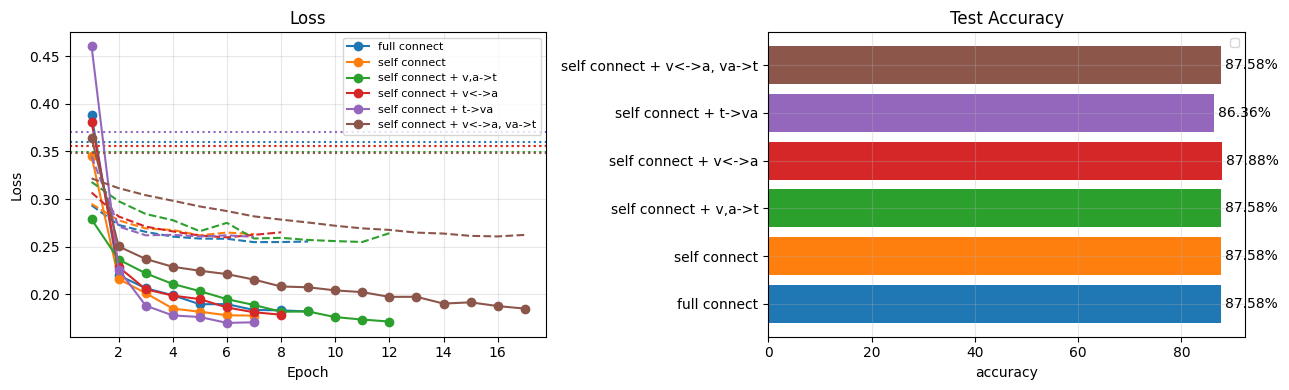


[self connect + v<->a, va->t] 최종 Test Acc: 87.58%
누적된 실험 (6개): ['full connect', 'self connect', 'self connect + v,a->t', 'self connect + v<->a', 'self connect + t->va', 'self connect + v<->a, va->t']


In [342]:
# 같은 이름이면 덮어씀 (중복 X)


fig_a, ax_a = plt.subplots(1, 2, figsize=(13, 4))
plt.close(fig_a)
# assign_results[run_name] = history
from IPython.display import display

for ax in ax_a:
    ax.clear()
for name, h in assign_results.items():
    ep = range(1, len(h["train_loss"]) + 1)
    line=ax_a[0].plot(ep, h["train_loss"], "-o", label=name)[0]
    ax_a[0].plot(ep, h['val_loss'],"--", color=line.get_color())
    ax_a[0].axhline(y=h['test_loss'], linestyle=":", color=line.get_color())
    bar=ax_a[1].barh(y=name, width=h['test_acc'])
    ax_a[1].bar_label( bar,  fmt="%.2f%%",  padding=3)


for ax in ax_a:
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax_a[0].set_title("Loss"); ax_a[0].set_xlabel("Epoch"); ax_a[0].set_ylabel("Loss")
ax_a[1].set_title("Test Accuracy"); ax_a[1].set_xlabel("accuracy")
fig_a.tight_layout()
display(fig_a)

print(f"\n[{run_name}] 최종 Test Acc: {history['test_acc']:.2f}%")
print(f"누적된 실험 ({len(assign_results)}개): {list(assign_results.keys())}")

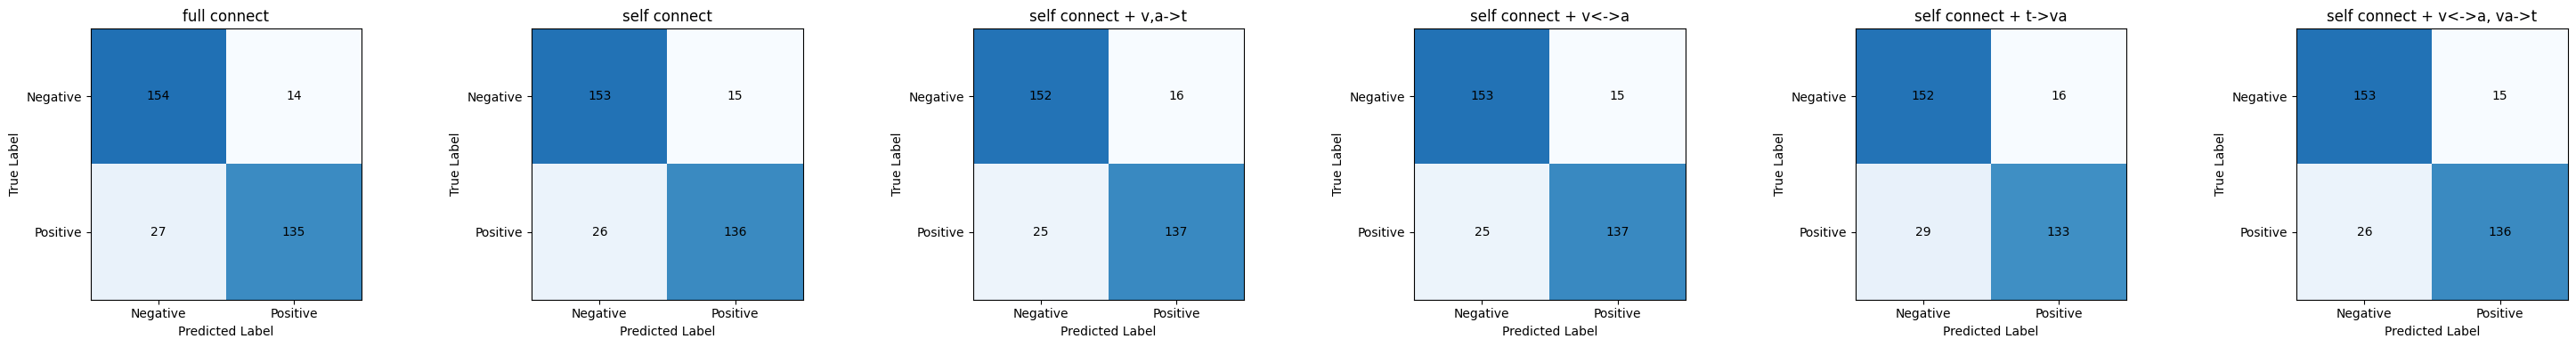

In [343]:
from sklearn.metrics import confusion_matrix
n = len(assign_results)

fig, axes = plt.subplots(1, n, figsize=(5*n, 4))

if n == 1:
    axes = [axes]

for ax, (name, result) in zip(axes, assign_results.items()):
    y_true = torch.cat(result["all_y"]).numpy()
    y_pred = torch.cat(result["all_pred"]).numpy()
    cm = confusion_matrix( y_true, y_pred )

    im = ax.imshow(cm, cmap="Blues",vmax=200)
    ax.set_title(name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center")

plt.tight_layout()
plt.show()